In [1]:
import icechunk
import xarray as xr
from srm import catalog
import duckdb
import boto3
import geopandas as gpd
import rasterix
import numpy as np
import pandas as pd
from rasterix.rasterize.rasterio import geometry_clip
import matplotlib.pyplot as plt
import seaborn as sns
from ibicus.debias import QuantileMapping

Load BCSD, model raw, and ERA5 datasets

In [12]:
bucket = "carbonplan-srm"
version = "0.1"
key = f"output/v{version}/example_SouthAfrica/pr_model_hist_BCSD_nonparametric.nc"

BCSD = xr.open_dataset(f"s3://{bucket}/{key}")["pr"]

BCSD = BCSD.drop_vars([v for v in ["dayofyear", "ensemble_member"] if v in BCSD.coords])
times = pd.to_datetime(BCSD.time.values.astype(str))
unique_times, index = np.unique(times, return_index=True)
BCSD = BCSD.isel(time=np.sort(index))
BCSD["time"] = unique_times
BCSD = BCSD.sel(latitude=slice(-22, -35), longitude=slice(16, 33))
BCSD = BCSD * 86400.0
BCSD.attrs["units"] = "mm/day"

In [3]:
storage = icechunk.s3_storage(
    bucket="carbonplan-srm", prefix="input/tensor/era5_rechunked_resampled.icechunk", from_env=True
)
repo = icechunk.Repository.open(storage)
session = repo.writable_session("main")
era5 = xr.open_zarr(session.store, consolidated=False)

ERA5 = era5["mean_total_precipitation_rate"]
ERA5 = ERA5.sel(time=slice("1978-01-01", "2014-12-31"))
ERA5 = ERA5.sel(latitude=slice(-22, -35), longitude=slice(16, 33))
ERA5 = ERA5 * 86400.0
ERA5.attrs["units"] = "mm/day"

In [4]:
storage = icechunk.s3_storage(
    bucket="carbonplan-srm",
    prefix="input/tensor/CESM2-WACCM-Historical/icechunk/icechunk",
    from_env=True,
)

repo = icechunk.Repository.open(storage)
session = repo.writable_session("main")

ds_hist = xr.open_zarr(session.store, consolidated=False)
HIST = ds_hist["PRECT"]

times = pd.to_datetime(HIST.time.values.astype(str))
unique_times, index = np.unique(times, return_index=True)
HIST = HIST.isel(time=np.sort(index))
HIST["time"] = unique_times
HIST = HIST.sel(time=slice("1978-01-01", "2014-12-31"))
HIST = HIST.sel(lat=slice(-35, -22), lon=slice(16, 33))
HIST = HIST * 1000.0 * 86400.0
HIST.attrs["units"] = "mm/day"

In [13]:
version = "0.1"
key_g6 = f"output/v{version}/example_SouthAfrica/pr_g61pt5k_BCSD_nonparametric.nc"

local_g6 = key_g6.split("/")[-1]

ds_g6 = xr.open_dataset(f"s3://{bucket}/{key}")
CESM_BCSD_g61pt5k = ds_g6["pr"]

CESM_BCSD_g61pt5k = CESM_BCSD_g61pt5k.drop_vars(
    [v for v in ["dayofyear", "ensemble_member"] if v in CESM_BCSD_g61pt5k.coords], errors="ignore"
)

times = pd.to_datetime(CESM_BCSD_g61pt5k.time.values.astype(str))
unique_times, index = np.unique(times, return_index=True)
CESM_BCSD_g61pt5k = CESM_BCSD_g61pt5k.isel(time=np.sort(index))
CESM_BCSD_g61pt5k["time"] = unique_times

CESM_BCSD_g61pt5k = CESM_BCSD_g61pt5k.sel(latitude=slice(-22, -35), longitude=slice(16, 33))

CESM_BCSD_g61pt5k = CESM_BCSD_g61pt5k * 86400.0
CESM_BCSD_g61pt5k.attrs["units"] = "mm/day"

In [14]:
version = "0.1"
key_ssp = f"output/v{version}/example_SouthAfrica/pr_ssp245_BCSD_nonparametric.nc"

ds_ssp = xr.open_dataset(f"s3://{bucket}/{key}")
CESM_BCSD_ssp245 = ds_ssp["pr"]

CESM_BCSD_ssp245 = CESM_BCSD_ssp245.drop_vars(
    [v for v in ["dayofyear", "ensemble_member"] if v in CESM_BCSD_ssp245.coords], errors="ignore"
)

times = pd.to_datetime(CESM_BCSD_ssp245.time.values.astype(str))
unique_times, index = np.unique(times, return_index=True)
CESM_BCSD_ssp245 = CESM_BCSD_ssp245.isel(time=np.sort(index))
CESM_BCSD_ssp245["time"] = unique_times

CESM_BCSD_ssp245 = CESM_BCSD_ssp245.sel(latitude=slice(-22, -35), longitude=slice(16, 33))

CESM_BCSD_ssp245 = CESM_BCSD_ssp245 * 86400.0
CESM_BCSD_ssp245.attrs["units"] = "mm/day"

Check for negative precip values

In [7]:
all_datasets = {
    "CESM_BCSD_g61pt5k": CESM_BCSD_g61pt5k,
    "CESM_BCSD_ssp245": CESM_BCSD_ssp245,
    "CESM_BCSD_hist": BCSD,
    "CESM_hist_raw": HIST,
    "ERA5": ERA5,
}

print("Percent of negative precipitation values v0.1:\n")

for name, da in all_datasets.items():
    neg = (da < 0).sum().compute()
    total = da.size
    pct = float(neg) / total * 100
    print(f"{name:20s}: {pct:.6f}%")

Percent of negative precipitation values v0.1:

CESM_BCSD_g61pt5k   : 33.292019%
CESM_BCSD_ssp245    : 33.292019%
CESM_BCSD_hist      : 33.292019%
CESM_hist_raw       : 0.000000%
ERA5                : 6.853288%


Histogram plotting function

In [37]:
###PLOTTING COLORS
#ERA5 = black,
#Model hist = blue dashed,
#Model SSP245 = Green dashed,
#Model G6-1.5K = Orange dashed,
#BCSD hist = Blue,
#BCSD SSP245 = Green,
#BCSD G6-1.5K = Orange

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def plot_precip_histograms(da1, da2, label1="Dataset 1", label2="Dataset 2",
                           title="Histogram of Precipitation Values", ymax=1_000_000):  

    """
    Plot histogram of precipitaiton values in two datasets 
    """
    
    vals1 = da1.values.flatten() if hasattr(da1, "values") else da1.flatten()
    vals2 = da2.values.flatten() if hasattr(da2, "values") else da2.flatten()
    
    vals1 = vals1[np.isfinite(vals1)]
    vals2 = vals2[np.isfinite(vals2)]
    
    xmin = min(vals1.min(), vals2.min())
    xmax = max(np.percentile(vals1, 99.9), np.percentile(vals2, 99.9))
    bins = np.linspace(xmin, xmax, 200)
    
    plt.figure(figsize=(8, 5))

    plt.hist(vals1, bins=bins, histtype="step", linewidth=2,
             label=label1,color="orange")
    plt.hist(vals2, bins=bins, histtype="step", linewidth=2,
             label=label2,color="black")

    plt.ylim(0, ymax)
    plt.xlabel("Precipitation value (mm/day)")
    plt.ylabel("Count")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

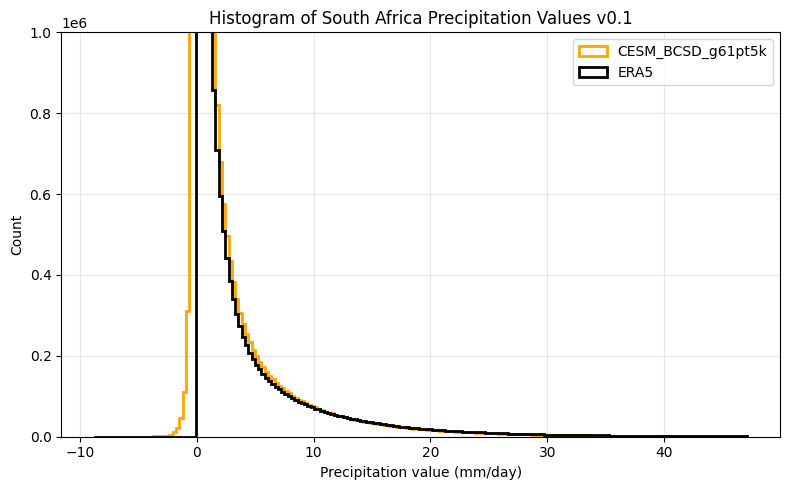

In [26]:
plot_precip_histograms(
    CESM_BCSD_g61pt5k,
    ERA5,
    label1="CESM_BCSD_g61pt5k",
    label2="ERA5",
    title="Histogram of South Africa Precipitation Values v0.1"
)

In [32]:
import numpy as np
import matplotlib.pyplot as plt

def plot_precip_hist_threshold(BCSD, ERA5, HIST, lat, lon,
                               threshold=10.0,
                               title="Histogram of Precip ≥ threshold"):
    """
    Plot histogram of precipitatoin values at lat lon point greater than specified threshold 
    """

    bcsd_ct = BCSD.sel(latitude=lat, longitude=lon, method="nearest")
    era_ct  = ERA5.sel(latitude=lat, longitude=lon, method="nearest")
    hist_ct = HIST.sel(lat=lat, lon=lon, method="nearest")

    h = hist_ct.values.astype(float).flatten()
    e = era_ct.values.astype(float).flatten()
    b = bcsd_ct.values.astype(float).flatten()

    h = h[np.isfinite(h)]
    e = e[np.isfinite(e)]
    b = b[np.isfinite(b)]

    h_hi = h[h >= threshold]
    e_hi = e[e >= threshold]
    b_hi = b[b >= threshold]

    xmin = threshold
    xmax = max(h_hi.max(), e_hi.max(), b_hi.max())
    bins = np.linspace(xmin, xmax, 40)

    plt.figure(figsize=(8, 5))

    plt.hist(b_hi, bins=bins, histtype="step", linewidth=2,
             label="BCSD_hist", color="blue")

    plt.hist(e_hi, bins=bins, histtype="step", linewidth=2,
             label="ERA5", color="black")

    plt.hist(h_hi, bins=bins, histtype="step", linewidth=2,
             label="CESM_hist", color="blue", linestyle="--")

    plt.xlabel("Daily precipitation (mm/day)")
    plt.ylabel("Count")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

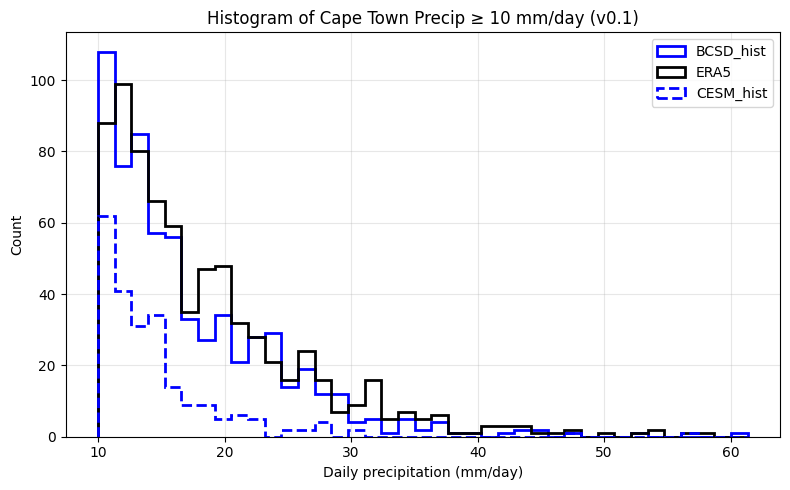

In [33]:
plot_precip_hist_threshold(
    BCSD, ERA5, HIST,
    lat=-33.9, lon=18.4,
    threshold=10.0,
    title="Histogram of Cape Town Precip ≥ 10 mm/day (v0.1)"
)

In [34]:
import numpy as np

def print_precip_percentiles(BCSD, ERA5, HIST, lat, lon, percentiles=[90, 95, 99]):
    """
    Print percentiles of precipitation (mm/day) for a single gridcell
    from BCSD, ERA5, and HIST datasets.
    """

    # Select gridcell
    bcsd_ct = BCSD.sel(latitude=lat, longitude=lon, method="nearest")
    era_ct  = ERA5.sel(latitude=lat, longitude=lon, method="nearest")
    hist_ct = HIST.sel(lat=lat, lon=lon, method="nearest")

    h = hist_ct.values.astype(float).flatten()
    e = era_ct.values.astype(float).flatten()
    b = bcsd_ct.values.astype(float).flatten()

    h = h[np.isfinite(h)]
    e = e[np.isfinite(e)]
    b = b[np.isfinite(b)]

    print(f"Percentiles for precipitation at lat={lat}, lon={lon}")
    for p in percentiles:
        print(f"\n{p}th percentile")
        print(f"CESM_hist: {np.percentile(h, p):.3f} mm/day")
        print(f"ERA5:      {np.percentile(e, p):.3f} mm/day")
        print(f"BCSD:      {np.percentile(b, p):.3f} mm/day")

In [36]:
#For Cape Town
print_precip_percentiles(
    BCSD, ERA5, HIST,
    lat=-33.9, lon=18.4
)

Percentiles for precipitation at lat=-33.9, lon=18.4

90th percentile
CESM_hist: 2.226 mm/day
ERA5:      5.460 mm/day
BCSD:      5.215 mm/day

95th percentile
CESM_hist: 4.797 mm/day
ERA5:      10.893 mm/day
BCSD:      9.577 mm/day

99th percentile
CESM_hist: 12.224 mm/day
ERA5:      24.287 mm/day
BCSD:      22.225 mm/day
